<a href="https://colab.research.google.com/github/Arati9703/student-performance-prediction-ml/blob/main/StudentPerformancePredictionML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step-1 : IMport all libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


STEP 2: Load Dataset

In [ ]:
df = pd.read_csv('/content/StudentsPerformance.csv')

STEP 3: EDA

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


STEP 4: Feature Engineering (Create Target)

In [ ]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

df['result'] = df['average_score'].apply(lambda x: 1 if x >= 40 else 0)

STEP 5: EDA (Visualization)

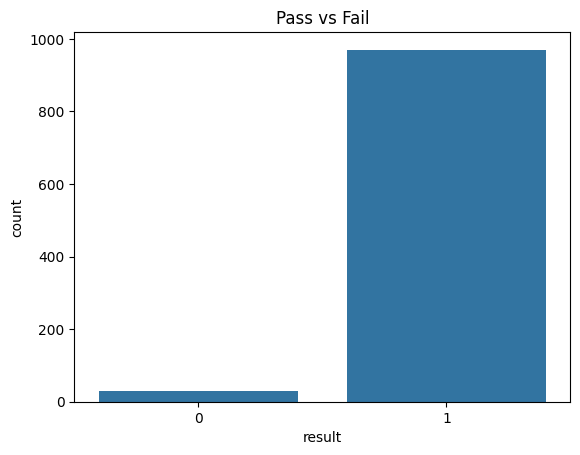

In [ ]:
#Pass vs Fail
sns.countplot(x='result', data=df)
plt.title("Pass vs Fail")
plt.show()

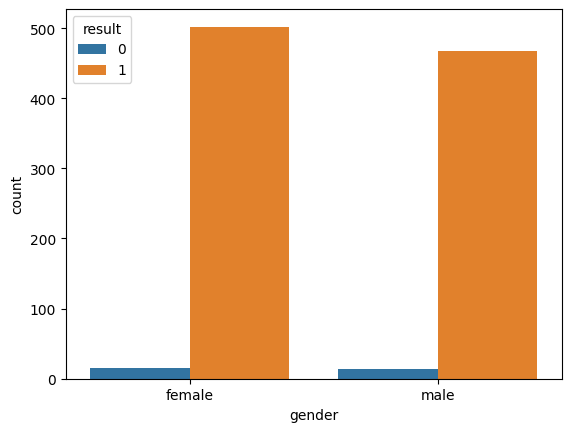

In [ ]:
#Gender vs Result
sns.countplot(x='gender', hue='result', data=df)
plt.show()

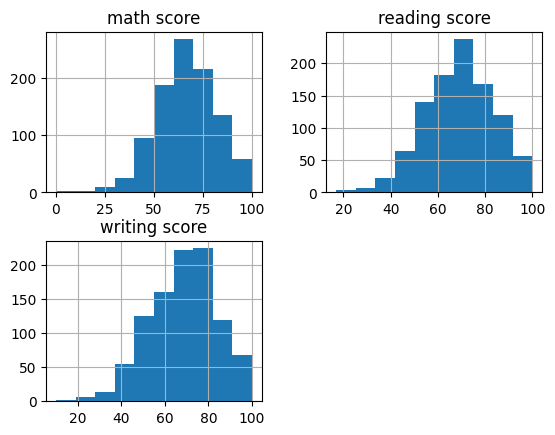

In [ ]:
#Score Distribution
df[['math score','reading score','writing score']].hist()
plt.show()

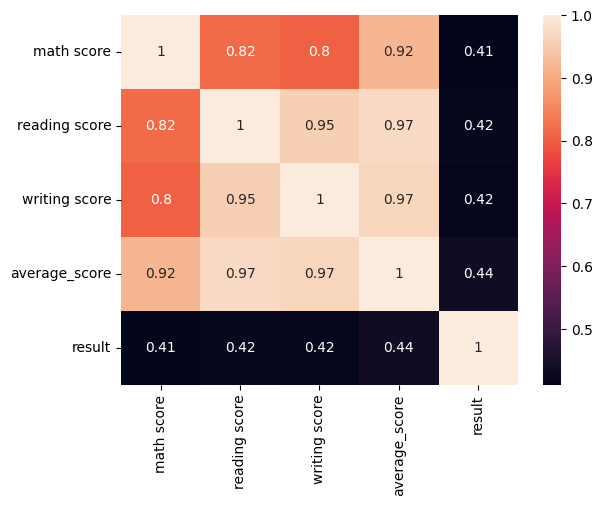

In [ ]:
# Correlation Heatmap (only numeric data)
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

STEP 6: Data Preprocessing

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,math score,reading score,writing score,average_score,result,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,72.666667,1,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,82.333333,1,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,92.666667,1,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,49.333333,1,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,76.333333,1,True,False,True,False,False,False,False,False,True,False,True,True


STEP 7: Define Features & Target

In [ ]:
X = df[['math score',
        'reading score',
        'writing score',
        'gender_male',
        'lunch_standard',
        'test preparation course_none']]
y = df['result']

In [ ]:
X.head(2)

,math score,reading score,writing score,gender_male,lunch_standard,test preparation course_none
0,72,72,74,False,True,True
1,69,90,88,False,True,False


STEP 8: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

STEP 9: Train Models

In [ ]:
lr = LogisticRegression()

In [ ]:
lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_lr

1.0

In [ ]:
dt = DecisionTreeClassifier()

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_dt

0.995

In [ ]:
rf = RandomForestClassifier()

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred_rf = rf.predict(X_test)
acc_rf  = accuracy_score(y_test,y_pred_rf)
acc_rf

0.995

In [ ]:
print("Logistic:", acc_lr)
print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)

Logistic: 1.0
Decision Tree: 0.995
Random Forest: 0.995


In [ ]:
confusion_matrix(y_test, y_pred_rf)

array([[  9,   1],
       [  0, 190]])

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.99      1.00      1.00       190

    accuracy                           0.99       200
   macro avg       1.00      0.95      0.97       200
weighted avg       1.00      0.99      0.99       200



In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic,1.000
1,Decision Tree,0.995
2,Random Forest,0.995


In [ ]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [ ]:
joblib.dump(dt, "decision_tree_model.pkl")

['decision_tree_model.pkl']

In [ ]:
from google.colab import files

files.download("random_forest_model.pkl")
files.download("decision_tree_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Loading models
rf_loaded = joblib.load("random_forest_model.pkl")
dt_loaded = joblib.load("decision_tree_model.pkl")

In [ ]:
rf_loaded.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [ ]:
!pip install gradio

In [ ]:
def predict_result(gender, test_prep, lunch, math, reading, writing):

    input_df = pd.DataFrame({
        'math score': [math],
        'reading score': [reading],
        'writing score': [writing],
        'gender_male': [1 if gender == "male" else 0],
        'lunch_standard': [1 if lunch == "standard" else 0],
        'test preparation course_none': [1 if test_prep == "none" else 0]
    })

    prediction = rf.predict(input_df)

    return "Pass" if prediction[0] == 1 else "Fail"

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_result,
    inputs=[
        gr.Radio(["male", "female"], label="Gender"),
        gr.Radio(["completed", "none"], label="Test Preparation"),
        gr.Radio(["standard", "free/reduced"], label="Lunch"),
        gr.Slider(0, 100, step=1, label="Math Score"),
        gr.Slider(0, 100, step=1, label="Reading Score"),
        gr.Slider(0, 100, step=1, label="Writing Score")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🎓 Student Performance Predictor",
    description="Enter student details to predict whether the student will Pass or Fail."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63728fe37cb33c417f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


female	group B	bachelor's degree	standard	none	72	72	74